# OFF -> S0

In [1]:
#user = r"\SagixOffice"  # HomeOffice
user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.miscellaneous as mi
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc
import src.figure as fi
import matplotlib.pyplot as plt

import numpy as np

%load_ext autoreload
%autoreload 2

C:\Users\vie43sq\Miniconda3\envs\MarkovModels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


In [2]:
number_fluorophores = 3
remove_transitions = ['OFRET', 'HFRET', 'CFRET', 'STA']
transition = 'OXI'
rate = 1e-2
bleaching = False

wavelength = 640
irradiance = 2.5

photon_collection_rate = 0.01
resample = '1ms'
emccd_gain = 100

end_time = 1000
seed = 3

rng = np.random.default_rng(seed)
fluorophores = fl.construct_fluorophores('cy5', 18, number_fluorophores)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = tr.load_transitions(fluorophore_system, irradiance=irradiance, wavelength=wavelength,
                                  bleaching=bleaching)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
transition_set = transition_set.adjust_rates({transition: rate})
transition_set.finalize()

simulation = si.Simulation(transition_set)
simulation.run(size=int(1e7), end_time=end_time, seed=rng, use_memmap=r'D:\memmaps\run 2')
emissions = em.Emissions(simulation, photon_collection_rate=photon_collection_rate,
                         resample=resample, emccd_gain=emccd_gain, seed=4)
blinking = bl.Blinking(emissions)
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-7, exp_max=1)
lifetimes = st.get_fluorescence_lifetime(simulation)

In [3]:
transition_set.transition_df

,transition_type,abbreviation,initial_state,final_state,rate,photon,energy_transfer,distance
id,,,,,,,,
0,TransitionType.EXCITATION,EXC,SingleState.S0,SingleState.S1,7.269626e+06,False,False,None
1,TransitionType.FLUORESCENT_EMISSION,FLU,SingleState.S1,SingleState.S0,2.700000e+08,True,False,None
2,TransitionType.INTERSYSTEM_CROSSING_ST,ISCST,SingleState.S1,SingleState.T1,8.300000e+05,False,False,None
3,TransitionType.INTERSYSTEM_CROSSING_TS,ISCTS,SingleState.T1,SingleState.S0,5.000000e+03,False,False,None
4,TransitionType.ISOMERIZATION,ISO,SingleState.S1,SingleState.Cis,2.000000e+07,False,False,None
5,TransitionType.BACKISOMERIZATION,BISO,SingleState.Cis,SingleState.S0,1.369280e+05,False,False,None
6,TransitionType.INTERNAL_CONVERSION_S,ICS,SingleState.S1,SingleState.S0,7.091700e+08,False,False,None
7,TransitionType.ET_CYCLE_T,ETT,SingleState.T1,SingleState.S0,4.383440e+05,False,False,None
8,TransitionType.ET_CYCLE_S,ETS,SingleState.S1,SingleState.S0,4.383440e+06,False,False,None


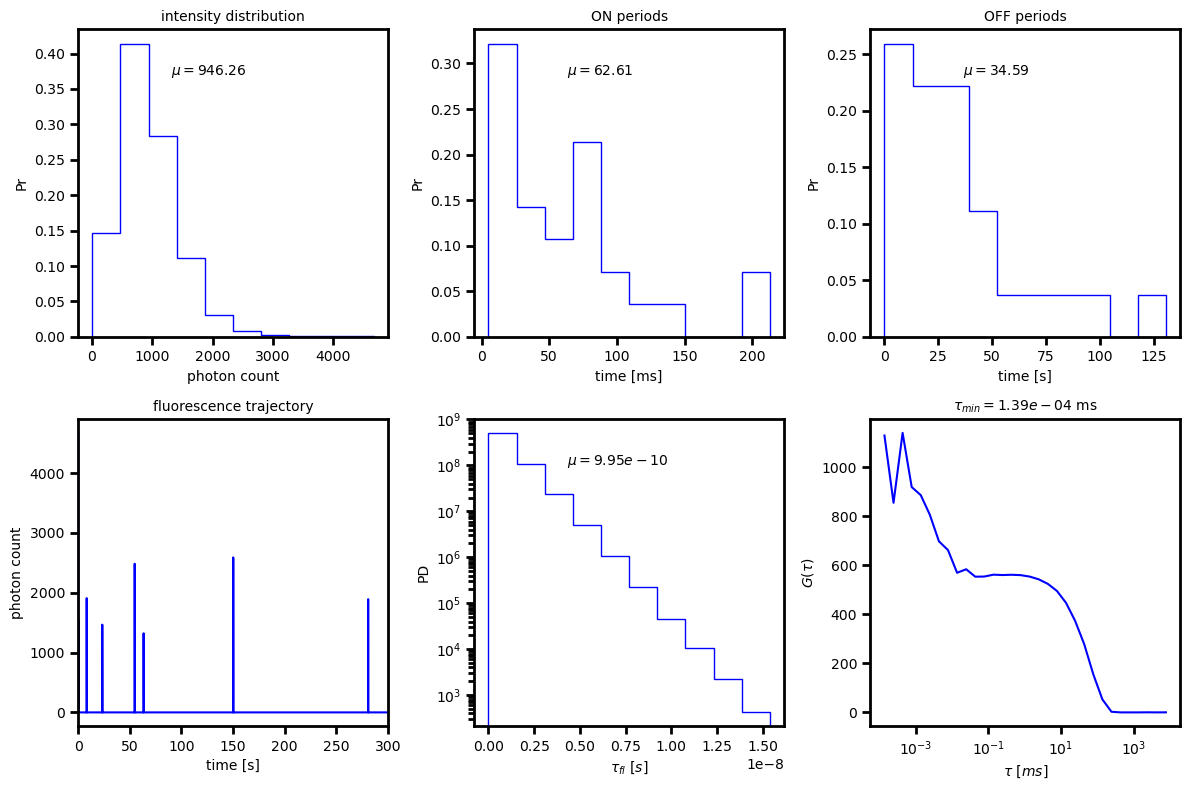

In [4]:
axes = emissions.plot(ncols=3, nrows=2, fig_height=8, fig_width=12,
                      mode='histogram', fontsize=10, density=False, histtype='step', display_mean=True)
blinking.plot(axes=axes[0, 1], mode='on_histogram', fontsize=10, display_mean=True, density=False,
              as_time='ms', histtype='step')
blinking.plot(axes=axes[0, 2], mode='off_histogram', fontsize=10, display_mean=True, density=False, 
              as_time='s', histtype='step')
emissions.plot(axes=axes[1, 0], mode='time_series', fontsize=10, xlim=[0, 300])
fi.universal_figure(type_='hist', data=[lifetimes], yscale='log', axes=axes[1, 1], fontsize=10,
                    histtype='step', xlabel=r'$\tau_{fl} \ [s]$', ylabel='PD', density=True)
axes[1, 1].text(x=0.3, y=0.85, s=fr'$\mu = {lifetimes.mean():.2e}$', transform=axes[1, 1].transAxes)
fcs.plot(axes=axes[1, 2], fontsize=10, unit='ms')
axes[0, 0].get_figure().tight_layout()

In [7]:
times_1, values_1 = bl.get_off_statistics(simulation, 0, event_indices=emissions.event_indices)
times_2, values_2 = bl.get_off_statistics(simulation, 1, event_indices=emissions.event_indices)

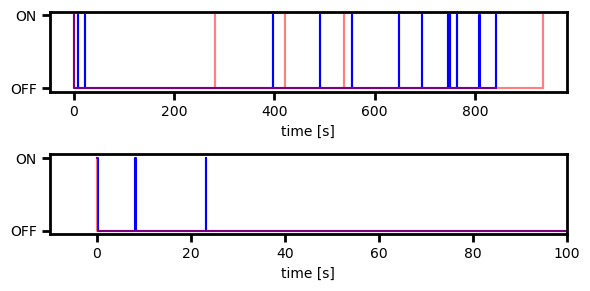

In [9]:
axes = fi.universal_figure(nrows=2, type_='line', data=[times_1, values_1])
fi.universal_figure(type_='line', data=[times_2, values_2], axes=axes[0, 0], color='r', alpha=0.5,
                   xlabel='time [s]', ylabel='', yticks=[0, 1], yticklabels={'labels':['OFF', 'ON']}, fontsize=10)
fi.universal_figure(type_='line', data=[times_1, values_1], xlim=[-10, 100], axes=axes[1, 0])
fi.universal_figure(type_='line', data=[times_2, values_2], xlim=[-10, 100], axes=axes[1, 0],
                   color='r', alpha=0.5, fontsize=10,
                   xlabel='time [s]', ylabel='', yticks=[0, 1], yticklabels={'labels':['OFF', 'ON']})
axes[0, 0].get_figure().tight_layout()